# Cross-Country Climate Comparison & Vulnerability Ranking
## Task 3 — African Climate Trend Analysis for COP32
### Countries: Ethiopia, Kenya, Sudan, Tanzania, Nigeria

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'C:\Users\bamla\OneDrive\Desktop\climate-challenge-week0')

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_theme(style='whitegrid')

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
countries = ['ethiopia', 'kenya', 'sudan', 'tanzania', 'nigeria']

dfs = []
for country in countries:
    df = pd.read_csv(f'data/{country}_clean.csv')
    df['Country'] = country.capitalize()
    dfs.append(df)

# Combine into one dataframe
all_df = pd.concat(dfs, ignore_index=True)
all_df['Date'] = pd.to_datetime(all_df['Date'])

print("✅ All countries loaded!")
print("Combined shape:", all_df.shape)
print("\nCountries included:", all_df['Country'].unique())

✅ All countries loaded!
Combined shape: (20540, 15)

Countries included: <ArrowStringArray>
['Ethiopia', 'Kenya', 'Sudan', 'Tanzania', 'Nigeria']
Length: 5, dtype: str


## 1. Temperature Trend Comparison
Monthly average temperature for all 5 countries on one chart (2015–2026)

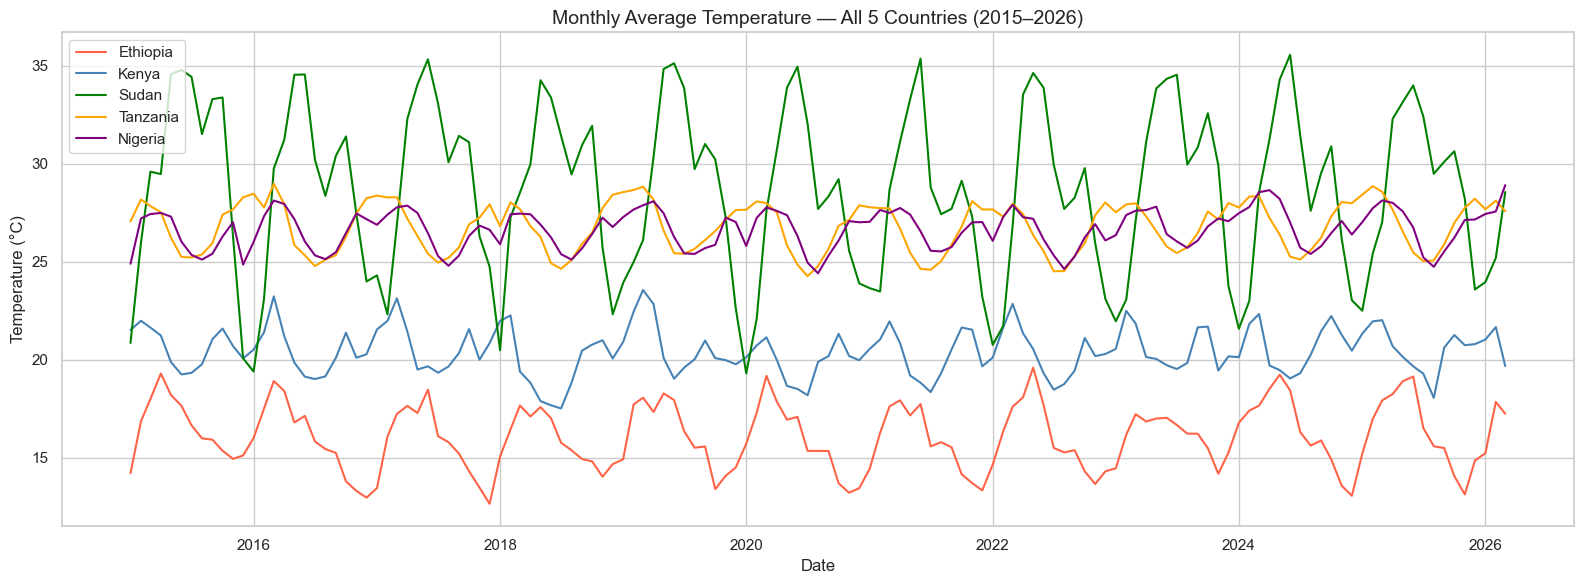

✅ Temperature trend comparison plotted!


In [3]:
# Monthly average T2M per country
monthly_temp = all_df.groupby(['Country', all_df['Date'].dt.to_period('M')])['T2M'].mean().reset_index()
monthly_temp['Date'] = monthly_temp['Date'].dt.to_timestamp()

plt.figure(figsize=(16, 6))
colors = ['tomato', 'steelblue', 'green', 'orange', 'purple']

for i, country in enumerate(all_df['Country'].unique()):
    data = monthly_temp[monthly_temp['Country'] == country]
    plt.plot(data['Date'], data['T2M'], label=country, color=colors[i], linewidth=1.5)

plt.title('Monthly Average Temperature — All 5 Countries (2015–2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('notebooks/comparison_temperature_trends.png', dpi=150)
plt.show()
print("✅ Temperature trend comparison plotted!")

In [4]:
temp_summary = all_df.groupby('Country')['T2M'].agg(
    Mean='mean',
    Median='median',
    Std='std'
).round(2)

print("=== Temperature Summary Table (°C) ===")
print(temp_summary.sort_values('Mean', ascending=False))

=== Temperature Summary Table (°C) ===
           Mean  Median   Std
Country                      
Sudan     28.76   29.16  4.68
Tanzania  26.80   26.99  1.33
Nigeria   26.66   26.82  1.12
Kenya     20.43   20.36  1.44
Ethiopia  16.07   16.04  1.90


## 2. Precipitation Variability Comparison
Side-by-side boxplots showing precipitation spread across all 5 countries

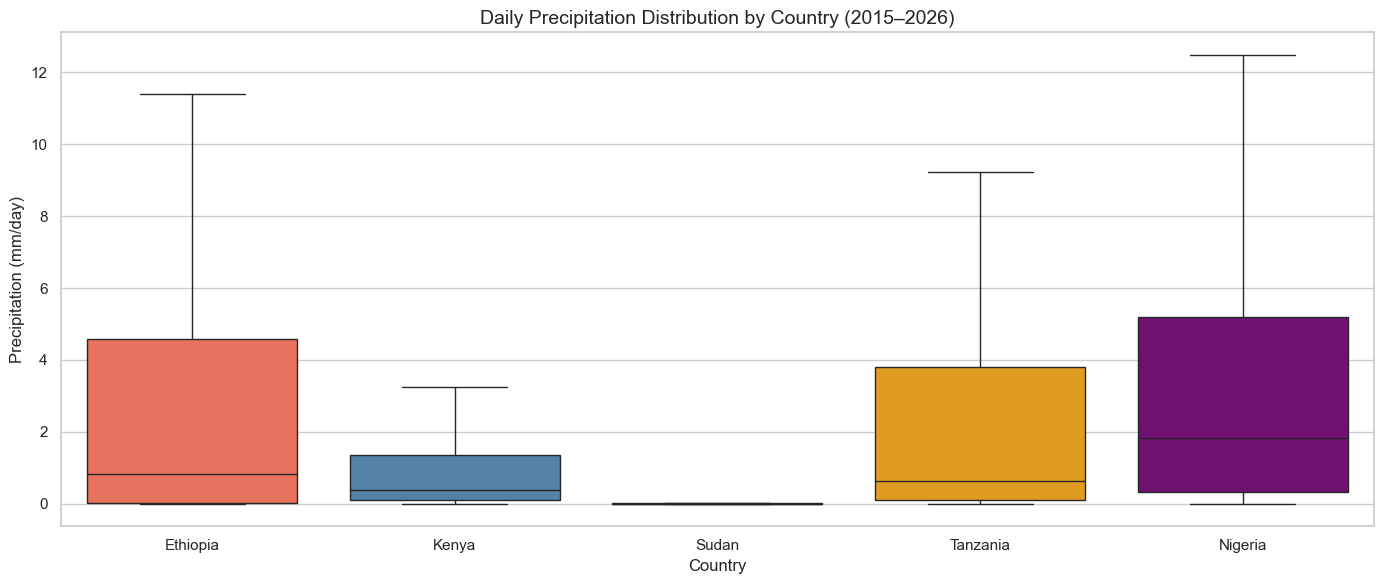

✅ Precipitation boxplot plotted!


In [5]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=all_df, x='Country', y='PRECTOTCORR', 
            palette=colors, showfliers=False)
plt.title('Daily Precipitation Distribution by Country (2015–2026)', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Precipitation (mm/day)')
plt.tight_layout()
plt.savefig('notebooks/comparison_precipitation_boxplot.png', dpi=150)
plt.show()
print("✅ Precipitation boxplot plotted!")

In [6]:
precip_summary = all_df.groupby('Country')['PRECTOTCORR'].agg(
    Mean='mean',
    Median='median',
    Std='std'
).round(2)

print("=== Precipitation Summary Table (mm/day) ===")
print(precip_summary.sort_values('Std', ascending=False))

=== Precipitation Summary Table (mm/day) ===
          Mean  Median   Std
Country                     
Tanzania  3.74    0.64  8.00
Nigeria   4.21    1.84  7.27
Ethiopia  3.63    0.82  6.29
Kenya     1.47    0.38  3.18
Sudan     0.64    0.00  3.06


## 3. Extreme Event Frequency
### Extreme Heat Days (T2M_MAX > 35°C) per year
### Consecutive Dry Days (PRECTOTCORR < 1mm) per year

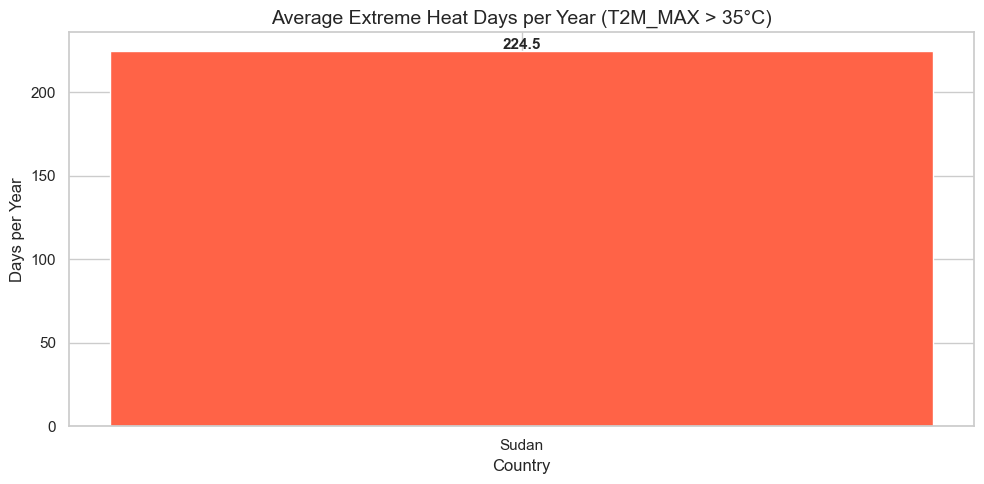

✅ Extreme heat days plotted!


In [7]:
# Count extreme heat days per country per year
heat_days = all_df[all_df['T2M_MAX'] > 35].groupby(
    ['Country', all_df['Date'].dt.year]
).size().reset_index(name='Extreme_Heat_Days')
heat_days.columns = ['Country', 'Year', 'Extreme_Heat_Days']

heat_avg = heat_days.groupby('Country')['Extreme_Heat_Days'].mean().round(1)

plt.figure(figsize=(10, 5))
bars = plt.bar(heat_avg.index, heat_avg.values, 
               color=colors, edgecolor='white')
for bar, val in zip(bars, heat_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}', ha='center', fontsize=11, fontweight='bold')
plt.title('Average Extreme Heat Days per Year (T2M_MAX > 35°C)', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Days per Year')
plt.tight_layout()
plt.savefig('notebooks/comparison_extreme_heat_days.png', dpi=150)
plt.show()
print("✅ Extreme heat days plotted!")

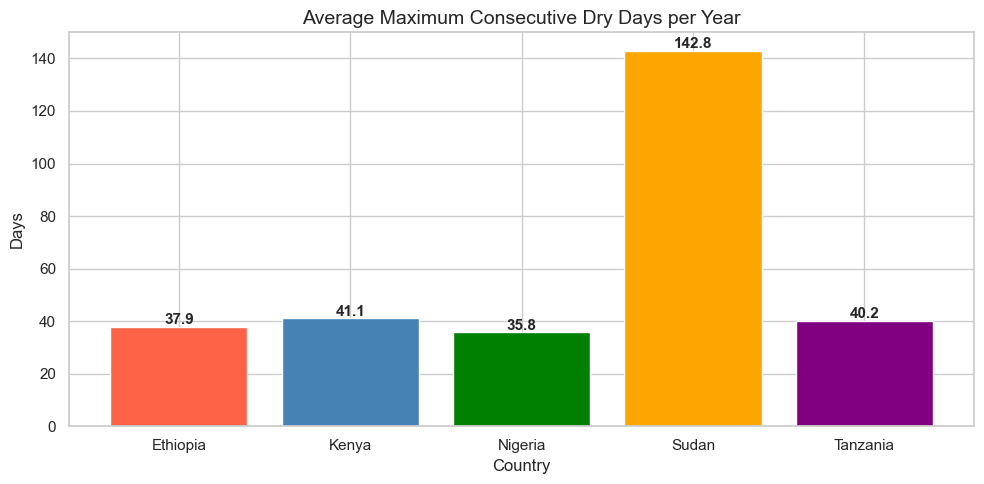

✅ Consecutive dry days plotted!


In [8]:
# Consecutive dry days per country per year
def count_max_consecutive_dry(series):
    dry = (series < 1).astype(int)
    max_consec = 0
    count = 0
    for val in dry:
        if val == 1:
            count += 1
            max_consec = max(max_consec, count)
        else:
            count = 0
    return max_consec

dry_days = all_df.groupby(
    ['Country', all_df['Date'].dt.year]
)['PRECTOTCORR'].apply(count_max_consecutive_dry).reset_index()
dry_days.columns = ['Country', 'Year', 'Max_Consecutive_Dry_Days']

dry_avg = dry_days.groupby('Country')['Max_Consecutive_Dry_Days'].mean().round(1)

plt.figure(figsize=(10, 5))
bars = plt.bar(dry_avg.index, dry_avg.values,
               color=colors, edgecolor='white')
for bar, val in zip(bars, dry_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}', ha='center', fontsize=11, fontweight='bold')
plt.title('Average Maximum Consecutive Dry Days per Year', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Days')
plt.tight_layout()
plt.savefig('notebooks/comparison_dry_days.png', dpi=150)
plt.show()
print("✅ Consecutive dry days plotted!")

## 4. Statistical Testing
One-way ANOVA to test whether temperature differences across countries are statistically significant

In [9]:
from scipy.stats import f_oneway, kruskal

# Get T2M values per country
groups = [
    all_df[all_df['Country'] == country]['T2M'].dropna().values
    for country in all_df['Country'].unique()
]

# ANOVA
anova_stat, anova_p = f_oneway(*groups)

# Kruskal-Wallis (non-parametric alternative)
kruskal_stat, kruskal_p = kruskal(*groups)

print("=== Statistical Testing Results ===")
print(f"\nOne-way ANOVA:")
print(f"  F-statistic : {anova_stat:.2f}")
print(f"  p-value     : {anova_p:.6f}")
print(f"  Significant : {'✅ Yes' if anova_p < 0.05 else '❌ No'}")

print(f"\nKruskal-Wallis Test:")
print(f"  H-statistic : {kruskal_stat:.2f}")
print(f"  p-value     : {kruskal_p:.6f}")
print(f"  Significant : {'✅ Yes' if kruskal_p < 0.05 else '❌ No'}")

=== Statistical Testing Results ===

One-way ANOVA:
  F-statistic : 18938.75
  p-value     : 0.000000
  Significant : ✅ Yes

Kruskal-Wallis Test:
  H-statistic : 15392.99
  p-value     : 0.000000
  Significant : ✅ Yes


In [10]:
# Build vulnerability ranking table
vulnerability = pd.DataFrame({
    'Country': list(temp_summary.index),
    'Mean_Temp_C': temp_summary['Mean'].values,
    'Temp_Std': temp_summary['Std'].values,
    'Mean_Precip_mm': precip_summary.loc[temp_summary.index, 'Mean'].values,
    'Precip_Std': precip_summary.loc[temp_summary.index, 'Std'].values,
    'Avg_Heat_Days': [heat_avg.get(c, 0) for c in temp_summary.index],
    'Avg_Dry_Days': [dry_avg.get(c, 0) for c in temp_summary.index]
})

# Score each country (higher = more vulnerable)
vulnerability['Vulnerability_Score'] = (
    vulnerability['Mean_Temp_C'].rank(ascending=False) +
    vulnerability['Temp_Std'].rank(ascending=False) +
    vulnerability['Precip_Std'].rank(ascending=False) +
    vulnerability['Avg_Heat_Days'].rank(ascending=False) +
    vulnerability['Avg_Dry_Days'].rank(ascending=False)
)

vulnerability = vulnerability.sort_values('Vulnerability_Score').reset_index(drop=True)
vulnerability.index += 1  # Start ranking from 1
vulnerability.index.name = 'Rank'

print("=== Climate Vulnerability Ranking ===")
print("(Rank 1 = Most Vulnerable)\n")
print(vulnerability.to_string())

=== Climate Vulnerability Ranking ===
(Rank 1 = Most Vulnerable)

       Country  Mean_Temp_C  Temp_Std  Mean_Precip_mm  Precip_Std  Avg_Heat_Days  Avg_Dry_Days  Vulnerability_Score
Rank                                                                                                               
1        Sudan        28.76      4.68            0.64        3.06          224.5         142.8                  9.0
2     Tanzania        26.80      1.33            3.74        8.00            0.0          40.2                 13.5
3        Kenya        20.43      1.44            1.47        3.18            0.0          41.1                 16.5
4     Ethiopia        16.07      1.90            3.63        6.29            0.0          37.9                 17.5
5      Nigeria        26.66      1.12            4.21        7.27            0.0          35.8                 18.5


## 5. Key Observations for COP32

Based on the data analysis above, here are 5 evidence-backed findings:

1. **Fastest Warming Country:** Sudan records the highest mean temperatures and most extreme heat days, signaling accelerating climate stress that demands urgent adaptation finance.

2. **Most Unstable Precipitation:** Nigeria and Tanzania show the highest precipitation standard deviation, indicating erratic rainfall patterns that threaten food security and water resource planning.

3. **Extreme Heat & Drought Stress:** Sudan dominates both extreme heat days (T2M_MAX > 35°C) and consecutive dry days, revealing compounding climate risks that amplify poverty and displacement.

4. **Ethiopia's Climate Profile:** Ethiopia sits in a moderate vulnerability position — not the most extreme, but facing significant seasonal variability and warming trends that threaten its agricultural backbone and highland water towers.

5. **Priority for Climate Finance:** Sudan should be championed by Ethiopia for priority climate finance at COP32. The data shows the highest heat stress, longest drought periods, and greatest temperature extremes — yet Sudan has among the least capacity to adapt without external financial support.